# Monthly IC analysis for mutual fund predictors

This notebook reads the IC summary and monthly panel from CSVs, selects the top 25 PASS features, computes their pairwise Spearman correlations, and reports the results.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ML_FILE = "feature_selection_output/ml_feature_dataset.csv"

df = pd.read_csv(ML_FILE)

print("Shape:", df.shape)
print(df.columns.tolist())

Shape: (7034, 29)
['scheme_name', 'month_date', 'target_month', 'outperforms_benchmark', 't_hml_250', 't_hml_750', 't_hml_180', 'sr_p1y', 'ir_p1y', 'ir_p6m', 'monthly_return_percent', 't_const_180', 'sr_p6m', 't_const_250', 'ir_p3y', 'const_90', 'const_180', 't_const_90', 't_const_120', 'const_250', 't_hml_120', 'const_120', 't_mkt_750', 't_umd_750', 't_hml_90', 'sr_p3y', 'r2_750', 'net_flow_percent', 't_smb_250']


## Read IC summary and monthly panel

Ensure the summary (ic_summary_all_features.csv) and monthly panel (ic_monthly_all_features.csv) are present.

In [4]:
NON_FEATURE_COLUMNS = [
    "scheme_name",
    "month_date",
    "target_month",
    "trade_month_end",
    "benchmark_name",
    "benchmark_month_end",
    "current_monthly_return_percent",
    "current_benchmark_monthly_return_percent",
    "monthly_return_percent",
    "benchmark_monthly_return_percent",
    "excess_return_percent",
    "outperforms_benchmark",
]

feature_columns = [
    c for c in df.columns
    if c not in NON_FEATURE_COLUMNS
]

print("Number of features:", len(feature_columns))
print("\nFeatures:")
for i, col in enumerate(feature_columns, 1):
    print(f"{i:2d}. {col}")

Number of features: 24

Features:
 1. t_hml_250
 2. t_hml_750
 3. t_hml_180
 4. sr_p1y
 5. ir_p1y
 6. ir_p6m
 7. t_const_180
 8. sr_p6m
 9. t_const_250
10. ir_p3y
11. const_90
12. const_180
13. t_const_90
14. t_const_120
15. const_250
16. t_hml_120
17. const_120
18. t_mkt_750
19. t_umd_750
20. t_hml_90
21. sr_p3y
22. r2_750
23. net_flow_percent
24. t_smb_250


## Select 25 PASS features

In [5]:
feature_matrix = df[feature_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

corr_matrix = feature_matrix.corr(method="spearman")

print("Correlation matrix shape:", corr_matrix.shape)

display(corr_matrix.round(3))

Correlation matrix shape: (24, 24)


,t_hml_250,t_hml_750,t_hml_180,sr_p1y,ir_p1y,ir_p6m,t_const_180,sr_p6m,t_const_250,ir_p3y,...,const_250,t_hml_120,const_120,t_mkt_750,t_umd_750,t_hml_90,sr_p3y,r2_750,net_flow_percent,t_smb_250
t_hml_250,1.000,0.820,0.931,0.138,0.050,-0.089,-0.190,0.206,-0.125,0.269,...,-0.128,0.841,-0.208,-0.069,-0.177,0.783,0.281,0.065,0.172,0.238
t_hml_750,0.820,1.000,0.763,0.050,0.041,-0.024,-0.065,0.095,-0.031,0.351,...,-0.046,0.695,-0.078,0.016,-0.212,0.645,0.326,0.167,0.277,0.122
t_hml_180,0.931,0.763,1.000,0.065,0.130,0.016,-0.071,0.091,-0.064,0.282,...,-0.065,0.928,-0.115,-0.052,-0.189,0.864,0.263,0.071,0.171,0.261
sr_p1y,0.138,0.050,0.065,1.000,-0.168,-0.134,-0.087,0.646,-0.049,-0.143,...,-0.025,0.007,-0.026,-0.190,-0.288,-0.018,0.377,-0.271,0.105,-0.235
ir_p1y,0.050,0.041,0.130,-0.168,1.000,0.675,0.768,-0.174,0.860,0.624,...,0.837,0.153,0.558,-0.018,0.173,0.170,0.241,0.087,0.277,-0.114
ir_p6m,-0.089,-0.024,0.016,-0.134,0.675,1.000,0.732,-0.179,0.568,0.343,...,0.553,0.074,0.819,0.124,0.048,0.081,-0.053,0.192,0.190,-0.085
t_const_180,-0.190,-0.065,-0.071,-0.087,0.768,0.732,1.000,-0.163,0.850,0.513,...,0.831,-0.039,0.780,0.015,0.067,-0.030,0.186,0.076,0.236,-0.191
sr_p6m,0.206,0.095,0.091,0.646,-0.174,-0.179,-0.163,1.000,-0.115,-0.066,...,-0.106,0.037,-0.045,-0.186,-0.128,0.035,0.491,-0.237,-0.026,-0.050
t_const_250,-0.125,-0.031,-0.064,-0.049,0.860,0.568,0.850,-0.115,1.000,0.628,...,0.980,-0.047,0.623,-0.102,0.097,-0.031,0.391,-0.032,0.275,-0.226
ir_p3y,0.269,0.351,0.282,-0.143,0.624,0.343,0.513,-0.066,0.628,1.000,...,0.585,0.263,0.326,-0.123,0.402,0.231,0.546,0.112,0.380,-0.268


## Prepare feature matrix

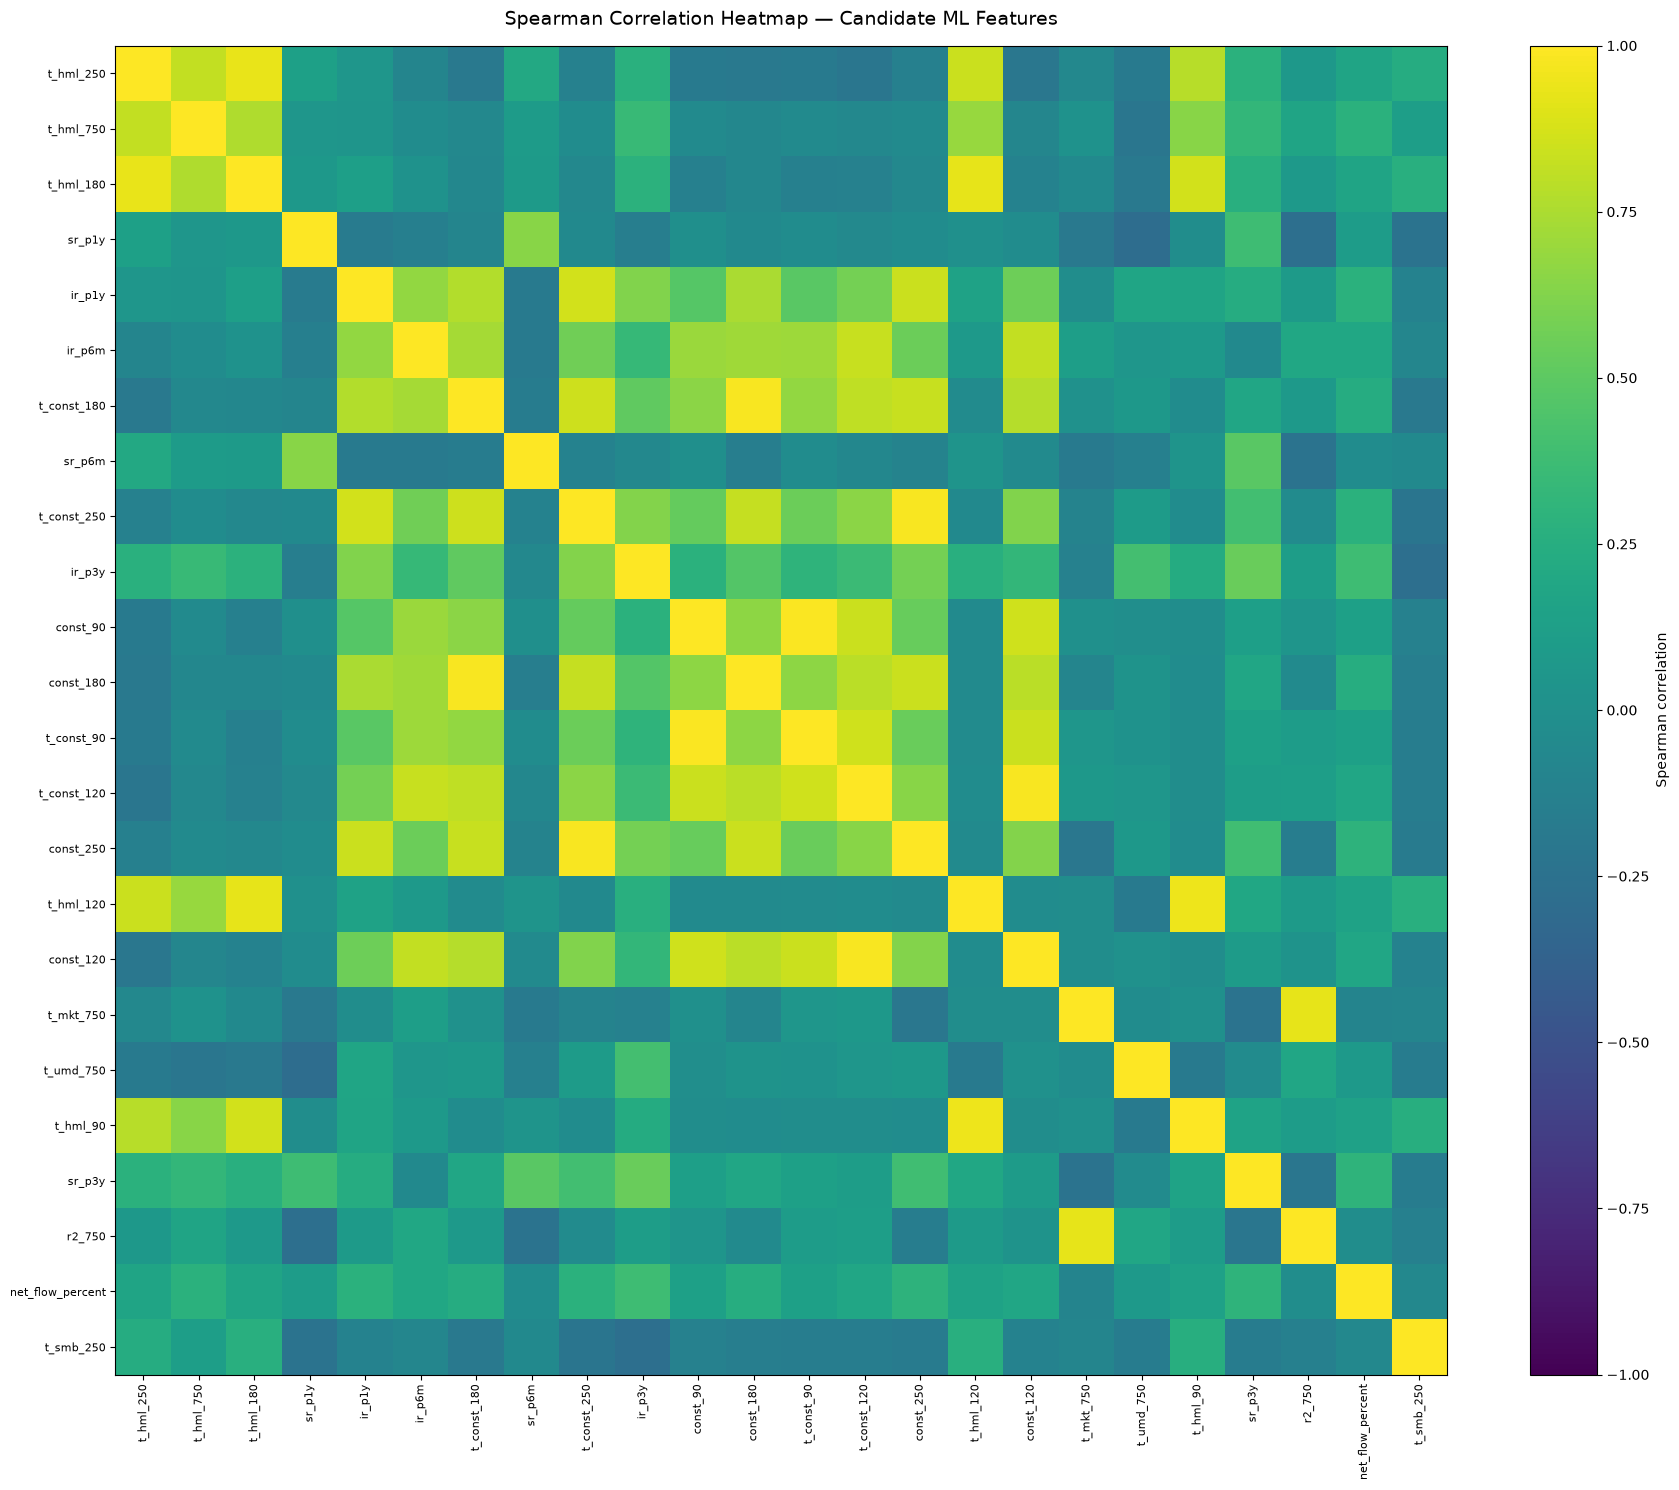

Saved heatmap to: feature_selection_output/feature_correlation_heatmap.png


In [6]:
fig, ax = plt.subplots(
    figsize=(18, 15)
)

im = ax.imshow(
    corr_matrix,
    aspect="auto",
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))

ax.set_xticklabels(
    corr_matrix.columns,
    rotation=90,
    fontsize=8
)

ax.set_yticklabels(
    corr_matrix.index,
    fontsize=8
)

ax.set_title(
    "Spearman Correlation Heatmap — Candidate ML Features",
    fontsize=14,
    pad=15
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Spearman correlation")

plt.tight_layout()

HEATMAP_FILE = "feature_selection_output/feature_correlation_heatmap.png"
plt.savefig(
    HEATMAP_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved heatmap to: {HEATMAP_FILE}")

## Pairwise Spearman correlation

In [ ]:
pairwise_corr = feature_matrix.corr(method="spearman")# full correlation matrixprint("Full Spearman correlation matrix (rounded 6):")print(pairwise_corr.round(6).to_string())# pairs where |corr| > 0.03threshold = 0.03pairs = []cols = pairwise_corr.columns.tolist()for i,a in enumerate(cols):    for b in cols[i+1:]:        rho = pairwise_corr.loc[a,b]        if pd.notna(rho) and abs(rho) > threshold:            pairs.append((a,b,float(rho),abs(float(rho))))pairs_sorted = sorted(pairs, key=lambda x: x[3], reverse=True)print("
Pairs with |rho| > {:.3f}: {}
".format(threshold, len(pairs_sorted)))for a,b,rho,ab in pairs_sorted:    print(f"{a} | {b} | rho={rho:.6f} | abs={ab:.6f}")# ranked list (abs, a, b, rho)print("
Ranked list of correlated pairs (abs,rho,a,b):")for a,b,rho,ab in pairs_sorted:    print(f"{ab:.6f}	{a}	{b}	{rho:.6f}")

## Export results

Save the full matrix and pair list to CSVs.

In [ ]:
pairwise_corr.to_csv('pass_features_pairwise_spearman.csv')import csvwith open('pass_feature_pairs_gt_003.csv','w',newline='') as fh:    writer = csv.writer(fh)    writer.writerow(['feature_a','feature_b','rho','abs_rho'])    for a,b,rho,ab in pairs_sorted:        writer.writerow([a,b,rho,ab])print('Wrote pass_features_pairwise_spearman.csv and pass_feature_pairs_gt_003.csv')